## 분류 예습 정리

### 목차
1. 분류란?
2. 분류 모델
3. 분류 평가 지표
4. 하이퍼파라미터 최적화

---

### 1. 분류란?

1) **지도 학습**

- **회귀**
: 주어진 데이터(X)를 기반으로 정답(Y)을 잘 맞히는 함수를 찾는 문제

- **분류**
: 기존 데이터가 어떤 레이블에 속하는지 패턴을 인지한 뒤, 새로 관측된 데이터의 레이블을 판별하는 것

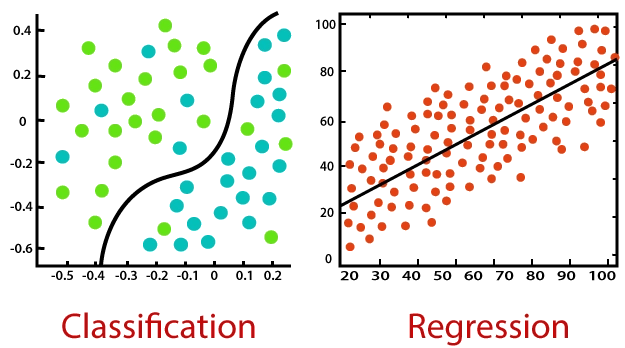

- 회귀와 분류의 차이
    - 회귀: 연속형 변수를 예측할 때
    - 분류: 범주형 변수를 예측할 때

- 분류에 쓰이는 대표적인 알고리즘
    1) 로지스틱 회귀: 독립변수와 종속변수의 선형 관계성에 기반해 분류
    2) 결정 트리: 데이터 균일도에 따른 규칙 기반의 분류
    3) 서포트 벡터 머신(SVM): 개별 클래스 간의 최대 마진을 찾아 분류
    4) 최소 근접(Nearest Neighbor): 근접 거리 기준으로 분류

2) **이진 분류와 다중 분류**

- 이진 분류(Binary Classification): 예측하려는 변수가 참/거짓 두 값만 가질 때
- 다중 분류(Multiclass Classification): 예측하려는 변수가 가질 수 있는 값이 3개 이상일 때

---

### 2. 분류 모델

1) **로지스틱 회귀 (Logistic Regression)**
: 샘플이 특정 클래스에 속할 확률을 추정해 기준치에 따라 분류하는 이진 분류 대표 알고리즘

- **로지스틱 회귀의 필요성**
    - 이진 분류를 단순 선형 회귀로 풀면 문제 발생
    - $y = wx + b$ 직선이 분류에 부적합한 이유
        1) $x$와 $y$의 관계 표현에는 **S자 형태**의 함수가 필요
        2) 예측값은 0과 1 사이여야 하는데, 직선은 음의 무한대~양의 무한대 값을 가짐

- **시그모이드 함수 (Sigmoid function)**
: 출력이 0과 1 사이의 값을 가지면서 S자 형태로 그려지는 함수 (≈ 로지스틱 함수)

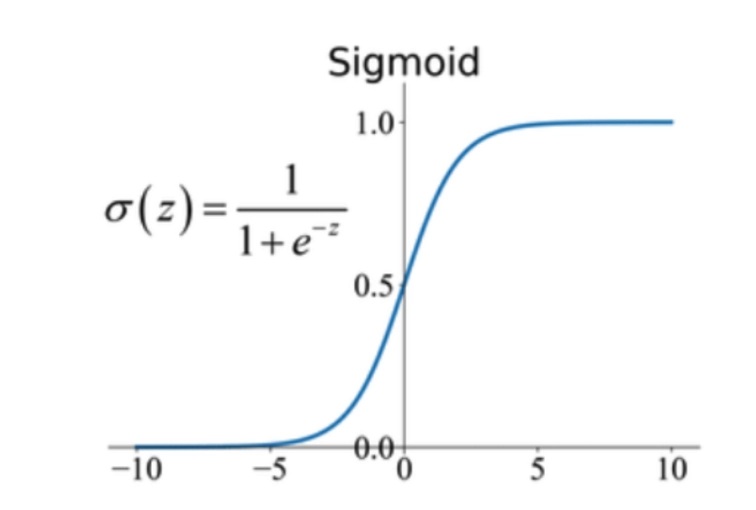

    - 특징
        - 입력값이 커지면 1에 수렴, 작아지면 0에 수렴
        - 입력값 $x$가 $(-\infty, \infty)$일 때 출력값 $y$는 0~1

- **시그모이드 함수의 가중치**

$$
H(x) = \frac{1}{1 + e^{-(wx+b)}} = sigmoid(wx+b) = \sigma(wx+b)
$$

    - 인공지능은 주어진 데이터에 적합한 가중치 $w$와 $b$를 계산해서 찾음
        - 가중치 $w$의 변화: 그래프의 기울기 변화 
        - 가중치 $b$의 변화: 그래프의 위치 변화 

2) **의사결정나무 (Decision Tree)**
: 조건에 따라 데이터를 분류하며, 최종적으로 데이터가 순수한 label의 집합이 될 때까지 분류를 반복하는 분석 방법

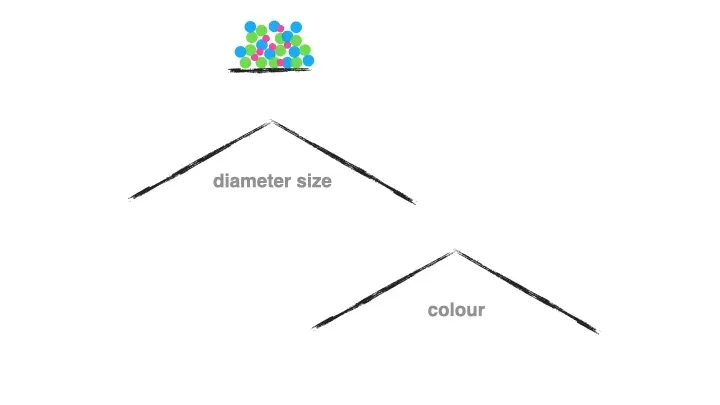

- 의사결정나무의 구성 요소

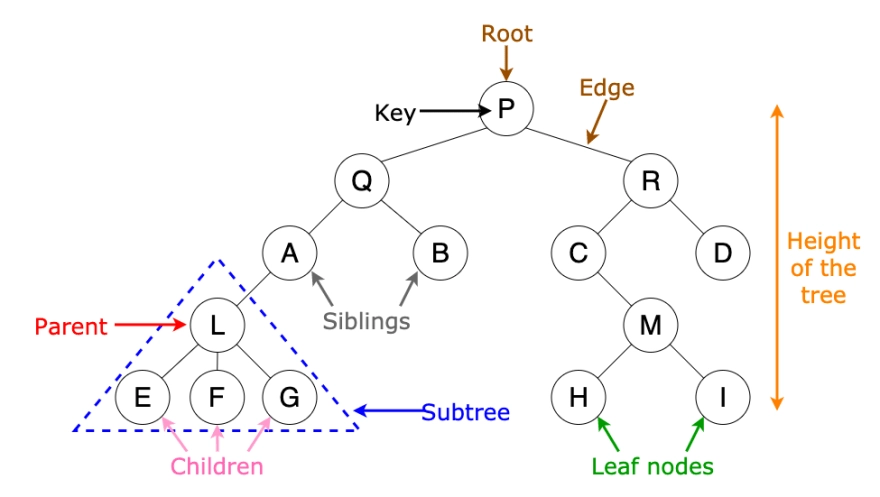

    - Root Node: 가장 상위에 위치한 노드
    - Parent Node: 주어진 노드의 상위에 있는 노드
    - Child Node: 하나의 노드로부터 분리된 2개 이상의 노드들
    - Binary Tree: children이 최대 2개인 tree
    - Leaf Node: 자식마디가 없는 노드, 모델에서 label에 해당
    - Edge: parent node와 child node를 연결하는 연결선
    - Height: 특정 노드에서 가장 멀리 있는 leaf node까지 경로의 edge 개수
    - Depth: root node에서 특정 노드까지 도달하기 위한 edge의 수

- **CART (Classification And Regression Tree) 알고리즘**
: 데이터셋을 임계값 기준으로 두 child로 나누는, 가장 널리 사용되는 의사결정나무 알고리즘
    - 임계값 기준: 불순도(지니 계수)가 낮아지는 방향
    - **불순도**: 분류하려는 데이터 집합에서 서로 다른 클래스(범주)가 섞여 있는 정도
    - 주요 단계
        1) 임계값 설정: $t_1...t_4$의 임계값을 기준으로 데이터를 그룹($R_1 ...R_5$)으로 나눔
        2) 불순도 감소 알고리즘: 동일한 객체들로 잘 모아지는 분류 기준을 찾아, 불순도가 낮은 쪽으로 가지를 형성
    - 한계: Greedy Algorithm

- 실제 학습 시 고려할 것
    1) Hyperparameter 설정
        - `min_samples_split`: 분할되기 위해 노드가 가져야 하는 최소 샘플 수
        - `min_samples_leaf`: 리프 노드가 가지고 있어야 하는 최소 샘플 수
        - `min_weight_fraction_leaf`: 가중치가 부여된 전체 샘플 수에서의 비율
        - `max_leaf_nodes`: 리프 노드의 최대 개수
        - `max_features`: 각 노드에서 분할에 사용할 특성의 최대 수
    2) 시각화: 분류가 잘 이루어졌는지 확인 (규제가 없으면 과적합)
    3) **Pruning(가지치기)**: 불필요한 노드 제거
        - 노드가 너무 많아지면 과적합 확률 높음
        - 하부 트리를 제거해 일반화 성능을 높임 → 깊이와 결과의 개수가 줄어듦

3) **SVM (Support Vector Machine)**
: 데이터를 분리하는 초평면 중에서 데이터들과 가장 거리가 먼 초평면을 선택해 분리하는 지도 학습 기반의 이진 선형 분류 모델

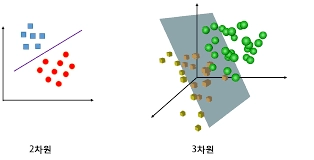

    - 명확하게 분류 가능한 데이터에서 뛰어난 성능, 고차원 공간에서도 효과적
    - 활용: 패턴 인식, 이미지 분석, 바이오인포매틱스

- SVM의 구성

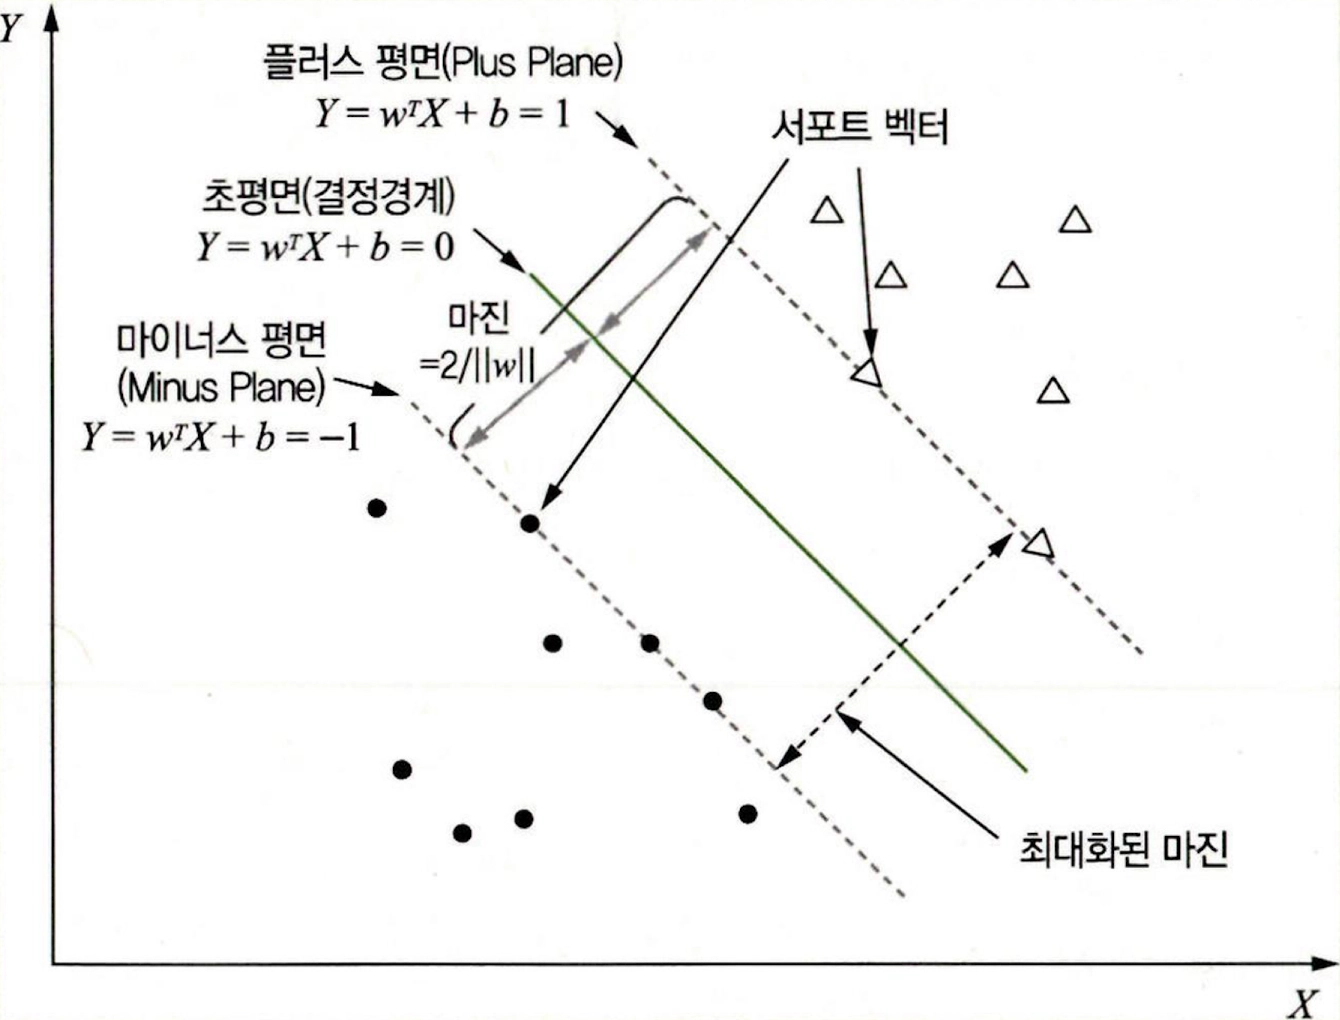

    - Support Vector: 결정 경계와 가장 가까이 있는 데이터들의 집합
    - Decision Boundary: 데이터 분류의 기준이 되는 경계
    - Margin: 결정 경계에서 서포트 벡터까지의 거리
    - Hyperplane: $n$차원 공간의 $(n-1)$차원 평면
    - Slack Variables: 완벽한 분리가 불가능할 때 허용된 오차에 대한 변수

- 최적의 선을 찾는 방법
    - 결정 경계는 데이터로부터 가장 멀리 떨어져 있는 것이 좋음
    - Margin이 가장 큰 경우를 선택

4) **KNN (K-Nearest Neighbor)**
: 데이터로부터 거리가 가까운 k개의 다른 데이터 레이블을 참조하여 분류하는 알고리즘

- KNN 알고리즘 계산 순서
    1) 데이터 준비: 특징 벡터 + 레이블
    2) K 값 설정: 가장 가까운 이웃의 개수 설정
    3) 거리 계산: 새로운 데이터와 기존 모든 데이터 간의 거리 계산 (유클리드 거리, 맨해튼 거리)
    4) 가장 가까운 K개의 이웃 선택
    5) 분류하기: K개의 이웃 중 가장 많이 등장하는 클래스가 예측 결과

- 최적의 K 선택하는 법
    - 일반적으로 데이터 개수의 제곱근 (실무에서는 교차 검증)
    - K가 너무 크면: 과소 적합
    - K가 너무 작으면: 이상값, 잡음 데이터와 이웃이 될 가능성

---

### 3. 분류 평가 지표

1) **혼동 행렬 (Confusion Matrix)**
: 분류 모델의 예측 결과를 정확한 예측과 잘못된 예측으로 구분하여 나타낸 표

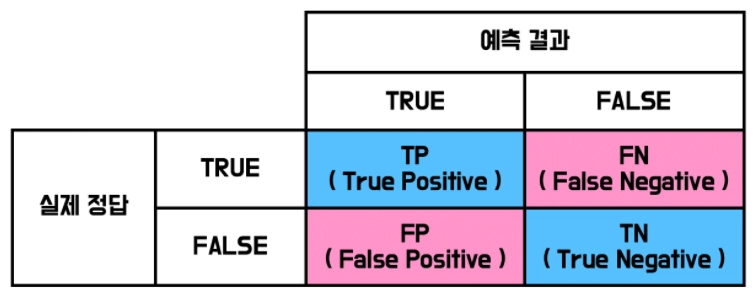

    - 예측 성공 여부(T/F) + 예측값(P/N)으로 구분하여 총 4종류

- 혼동 행렬을 이용한 평가 지표 (모두 0과 1 사이의 값)
    1) **정확도(Accuracy)**: 모든 가능한 예측 중 참인 비율
    2) **정밀도(Precision)**: 참이라고 예측한 경우 중 실제 참의 비율
    3) **재현도(Recall)**: 실제로 참인 경우 중 참으로 예측하는 비율

- Precision과 Recall의 Trade-off 관계
    - 확률에 기반해 Threshold 이상이면 참, 미만이면 거짓으로 판단
    - Threshold를 낮춤 → Positive 예측 증가 → Recall ↑, Precision ↓
    - Threshold를 높임 → Positive 예측 감소 → Recall ↓, Precision ↑

- 정밀도 & 재현도 그래프
    - Threshold 결정에 도움

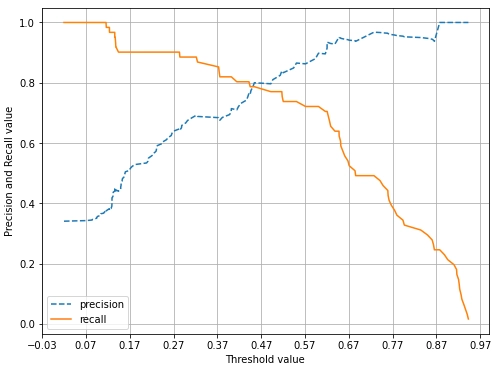

2) **F1-Score**
: 정밀도와 재현율의 조화 평균

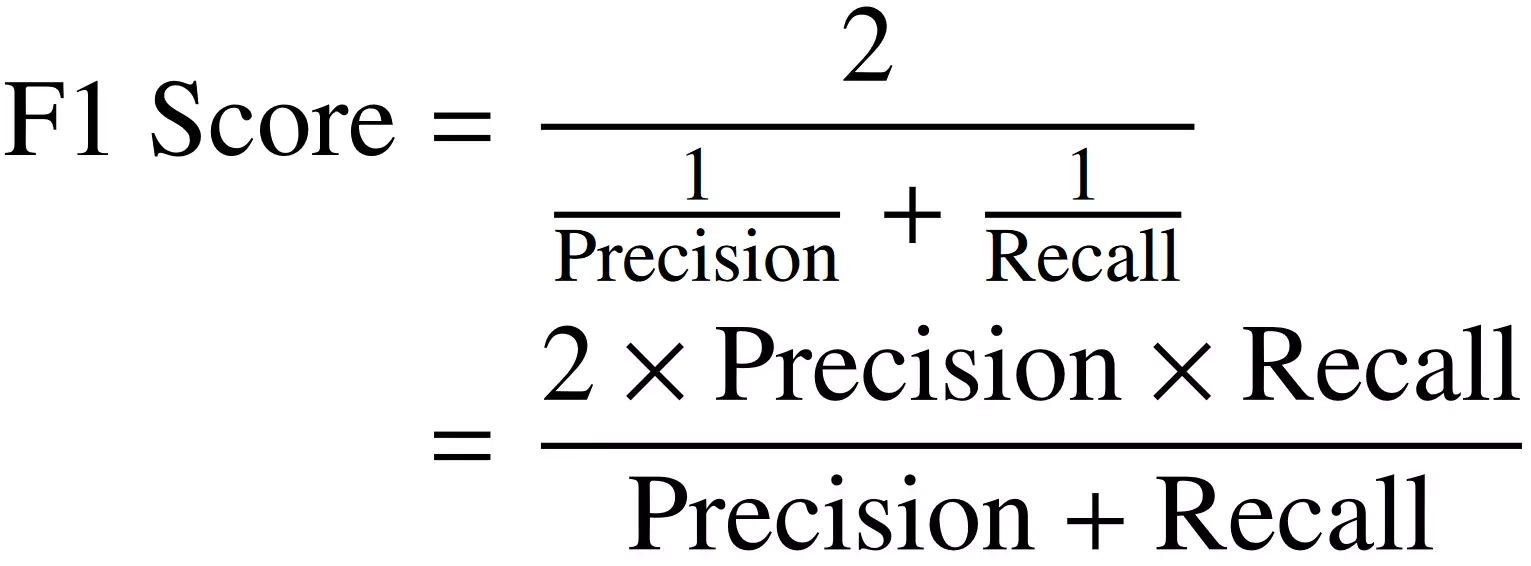

3) **ROC / AUC**

- **ROC Curve**: 얼마나 분류가 잘 되었는가를 보여주는 그래프

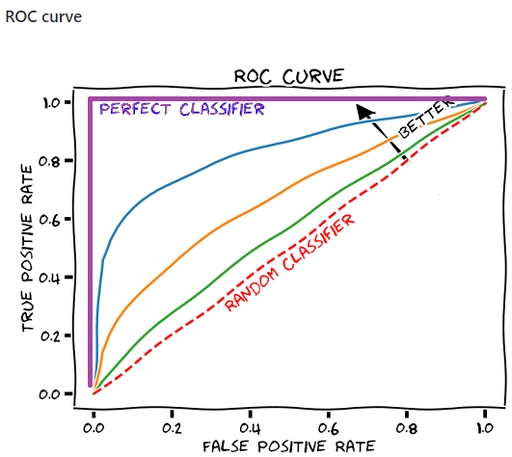

    - True Positive Rate(TPR): 참인 것들 중 참이라고 예측한 비율 (= Recall)
    - False Positive Rate(FPR): 거짓인 것들 중 참이라고 잘못 예측한 비율

- **AUC**: ROC와 x축 사이의 면적 (적분값)

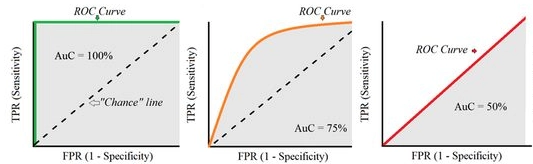

    - 모델의 성능을 숫자로 나타낼 수 있음
    - 0.5에서 1 사이의 값을 가지며, 1에 가까울수록 분류 성능이 좋음

---

### 4. 하이퍼파라미터 최적화

1) **하이퍼파라미터**
: 모델 학습 과정에 반영되는 값으로, 학습 시작 전에 사용자가 직접 설정하는 변수

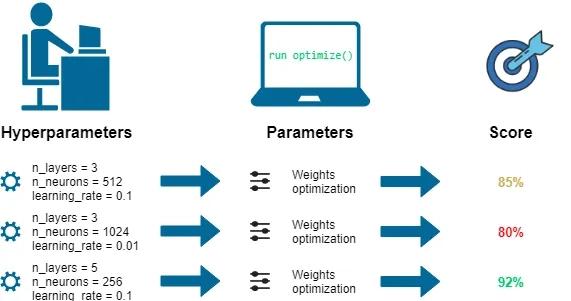

- **하이퍼파라미터 최적화**: Tuning을 거쳐 적절한 하이퍼파라미터를 찾아 모델 성능을 향상시키는 것

- 하이퍼파라미터 최적화 과정
    1) 탐색 범위 설정: 최적 값을 찾고 싶은 하이퍼파라미터의 범위 설정
    2) 평가 지표 계산 함수 정의: 하이퍼파라미터를 인수로 받아 평가지표 값을 계산하는 함수 정의
    3) 정확도 평가: 설정한 범위에서 샘플링한 값을 사용해 검증 데이터로 평가
    4) 반복: 정확도 결과를 보고 범위를 좁힘

2) **하이퍼파라미터 최적화 방법**

- **Grid Search**: 정해진 범위에서 하이퍼파라미터를 모두 순회하며 가장 좋은 성능을 내는 값을 찾는 기법 (`GridSearchCV`)
    - 장점: 정확성
    - 단점: 시간이 너무 오래 걸림
    - 적용: 넓은 범위, 큰 step을 활용해 범위를 좁힘

- **Random Search**: 정해진 범위에서 하이퍼파라미터를 무작위로 탐색하는 기법 (`RandomizedSearchCV`)
    - 장점: 속도가 Grid Search보다 빠름
    - 단점: 무작위라는 한계로 정확도가 떨어짐

- **Bayesian Optimization**: 사전 정보를 바탕으로 최적 하이퍼파라미터 값을 확률적으로 추정하며 탐색하는 기법 (`bayes_opt`)
    - 방법
        1) 초기 값 몇 개를 무작위로 실험
        2) 그 결과를 바탕으로 좋은 파라미터 조합을 확률 모델로 예측
        3) 다음 실험할 조합을 가장 좋을 것 같은 위치로 선택
        4) 결과를 반영하고 다시 반복